## 1. Environment Setup & Data Loading

In [195]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
os.makedirs('outputs/figures', exist_ok=True)


In [196]:
columns = (
    ['engine_id', 'cycle'] +
    [f'setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

train_raw = pd.read_csv(
    'data/train_FD001.txt',
    sep=r'\s+',
    header=None
)
train_raw = train_raw.iloc[:, :26]
train_raw.columns = columns

print('Train shape:', train_raw.shape)
train_raw.head()


Train shape: (20631, 26)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Target Variable (RUL) Definition

In [197]:
train = train_raw.copy()

max_cycle = train.groupby('engine_id')['cycle'].max()
train['RUL'] = train['engine_id'].map(max_cycle) - train['cycle']

train[['engine_id', 'cycle', 'RUL']].head()


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## 3. Exploratory Data Analysis (EDA)

In [198]:
all_sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
print(all_sensor_cols)


['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


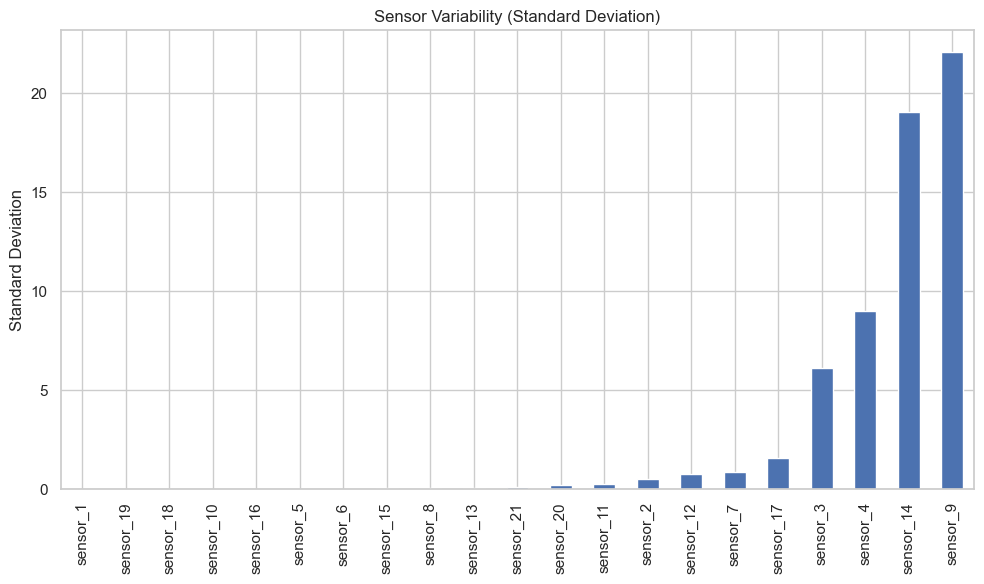

In [199]:
sensor_std = train[all_sensor_cols].std().sort_values()

plt.figure(figsize=(10, 6))
sensor_std.plot(kind='bar')
plt.title('Sensor Variability (Standard Deviation)')
plt.ylabel('Standard Deviation')
plt.tight_layout()
plt.savefig('outputs/figures/sensor_variability.png', dpi=120)
plt.show()


In [200]:
constant_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train = train.drop(columns=constant_sensors).copy()
print('After dropping constant sensors:', train.shape)


After dropping constant sensors: (20631, 21)


In [201]:
print(train.shape)


(20631, 21)


In [202]:
sensor_cols = [col for col in train.columns if col.startswith('sensor_')]
print(len(sensor_cols))
print(sensor_cols)


15
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


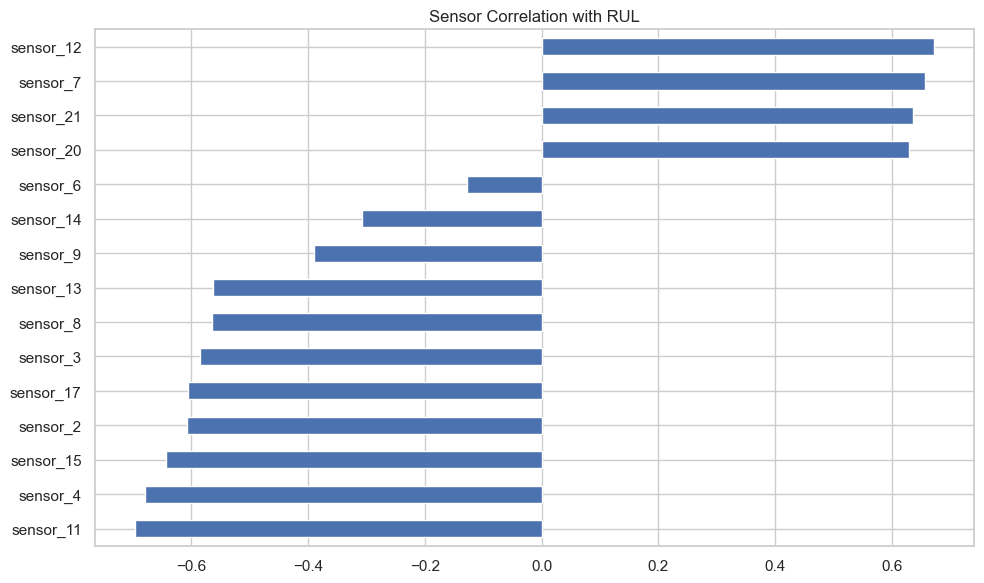

In [203]:
corr_with_rul = train[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')

corr_sorted = corr_with_rul.sort_values()

plt.figure(figsize=(10, 6))
corr_sorted.plot(kind='barh')
plt.title('Sensor Correlation with RUL')
plt.tight_layout()
plt.savefig('outputs/figures/sensor_rul_correlation.png', dpi=120)
plt.show()


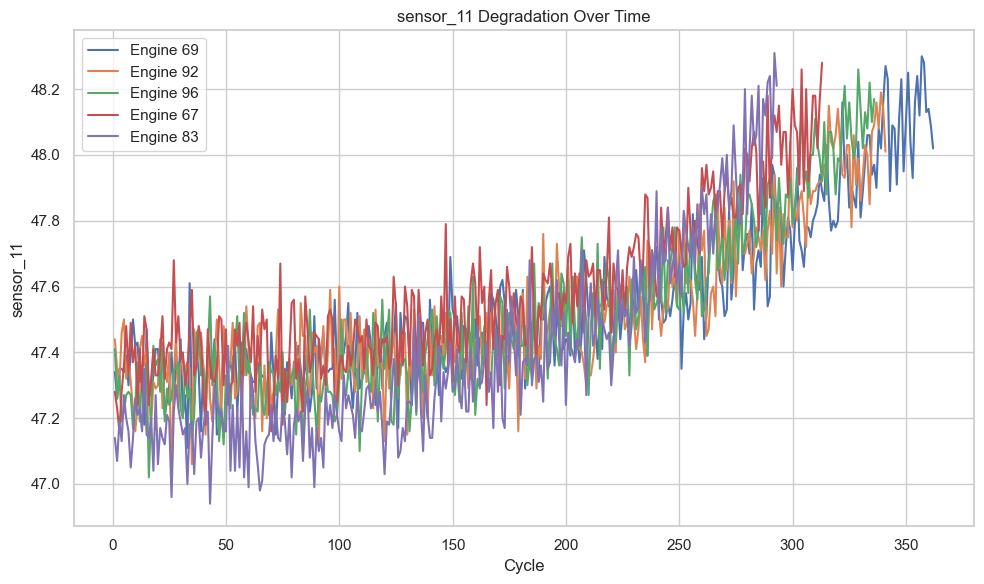

In [204]:
engine_cycles = train.groupby('engine_id')['cycle'].max()

sample_engines = engine_cycles.sort_values(ascending=False).head(5).index.tolist()

plt.figure(figsize=(10, 6))

for eng in sample_engines:
    subset = train[train['engine_id'] == eng]
    plt.plot(subset['cycle'], subset['sensor_11'], label=f'Engine {eng}')

plt.xlabel('Cycle')
plt.ylabel('sensor_11')
plt.title('sensor_11 Degradation Over Time')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/sensor11_degradation.png', dpi=120)
plt.show()


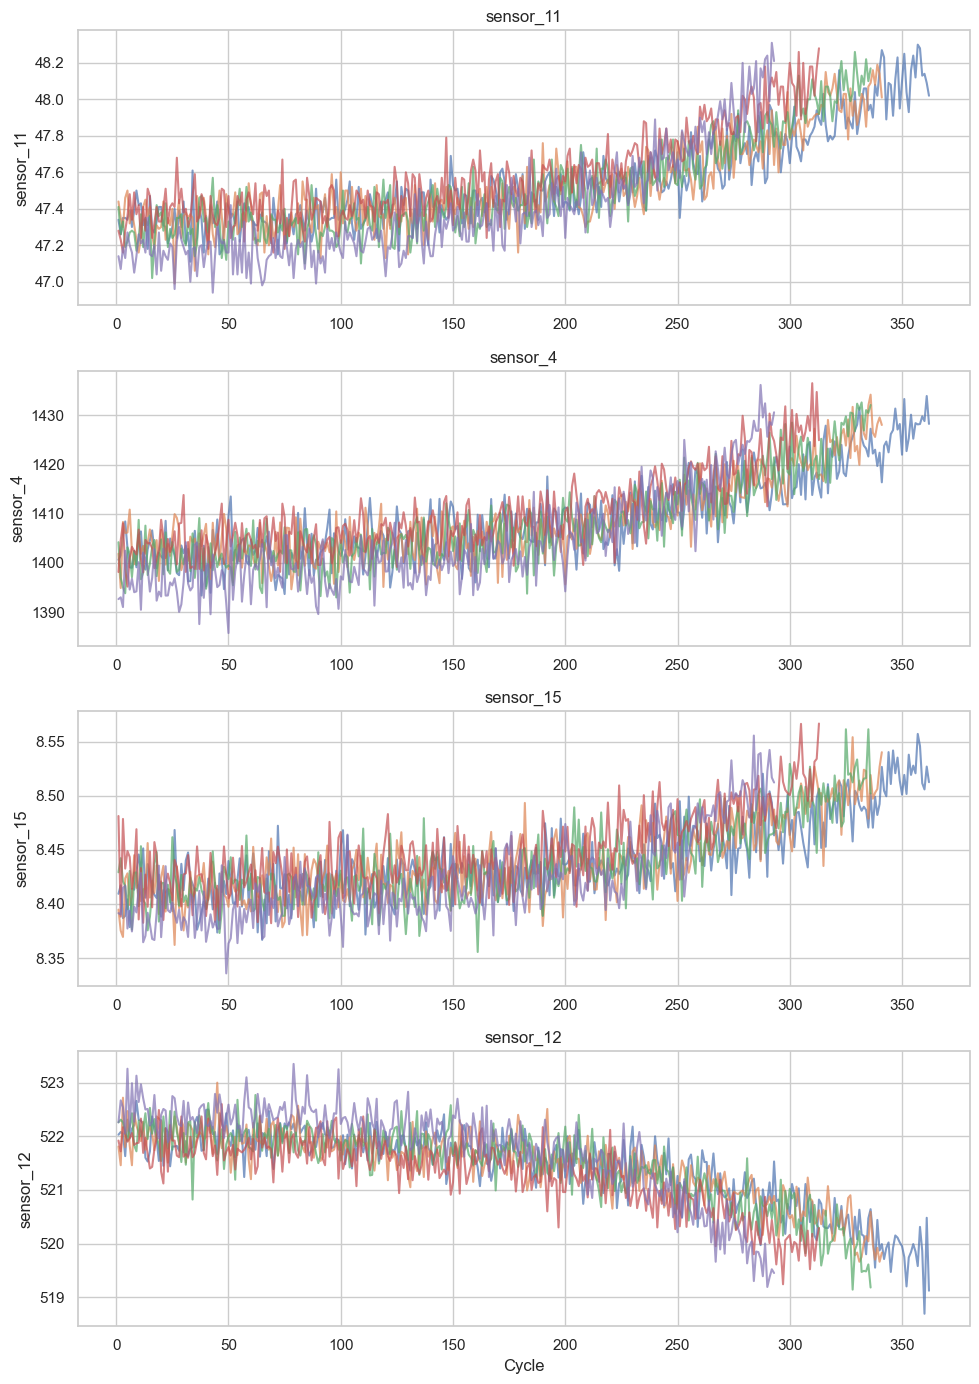

In [205]:
important_sensors = ['sensor_11', 'sensor_4', 'sensor_15', 'sensor_12']

sample = train[train['engine_id'].isin(sample_engines)]

fig, axes = plt.subplots(len(important_sensors), 1, figsize=(10, 14), sharex=False)

for ax, col in zip(axes, important_sensors):
    for eng in sample_engines:
        subset = sample[sample['engine_id'] == eng]
        ax.plot(subset['cycle'], subset[col], alpha=0.7, label=f'Engine {eng}')
    ax.set_title(col)
    ax.set_ylabel(col)

axes[-1].set_xlabel('Cycle')
plt.tight_layout()
plt.savefig('outputs/figures/key_sensor_trends.png', dpi=120)
plt.show()


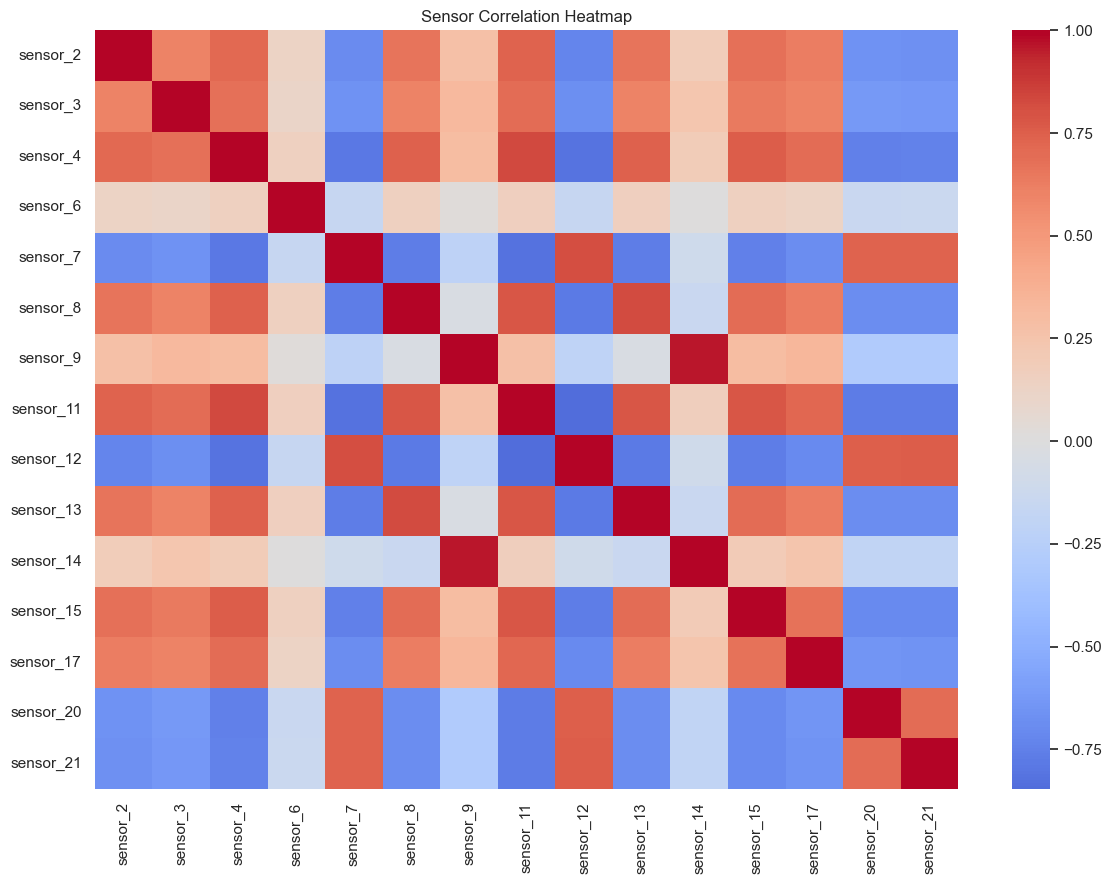

In [206]:
corr_matrix = train[sensor_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)

plt.title('Sensor Correlation Heatmap')

plt.tight_layout()
plt.savefig('outputs/figures/sensor_corr_heatmap.png', dpi=120)
plt.show()


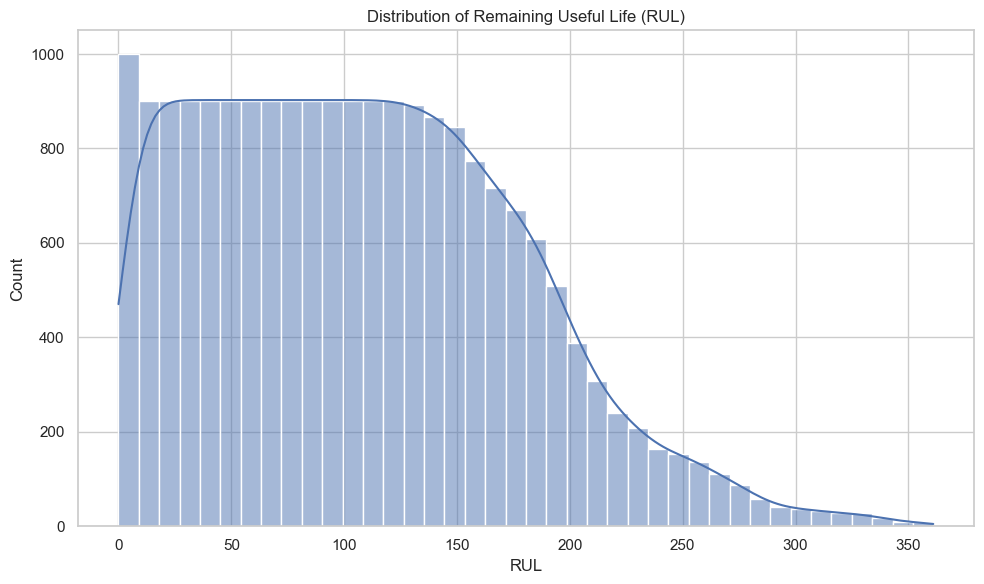

In [207]:
plt.figure(figsize=(10, 6))

sns.histplot(train['RUL'], bins=40, kde=True)

plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('RUL')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('outputs/figures/rul_distribution.png', dpi=120)
plt.show()


In [208]:
train_model = train.copy()

print(train_model.shape)


(20631, 21)


## 4. Feature Engineering

### 4-1. Review and Improvement of Engineered Features

**Existing Engineered Features:**
- `rolling_mean(window=5)`, `rolling_std(window=5)`: Short-term rolling statistics
- `diff`: 1-step change rate

**Issues and Improvements:**

| Improvement Item | Rationale |
|---|---|
| **Multi-window rolling** (w=5,10,20) | A single window=5 is sensitive to short-term noise -> Capture mid-term (10) and long-term (20) trends simultaneously |
| **EWMA** (span=10) | Higher weight on recent cycles, improving robustness against noise |
| **Cumulative stats** (cmin/cmax/crange) | Cumulatively track overall degradation range per engine to reflect health state baseline |
| **Degradation ratio** (rolling_mean / initial_mean) | Normalize current degradation relative to initial state -> Enables comparison across engines |
| **RUL Capping** (≤125) | Extreme RUL values at early cycles disrupt model training -> Standard CMAPSS approach |

> ⚠️ `cycle_ratio` (current cycle / max cycle) uses the engine's actual lifespan (future information) at the test stage, causing **data leakage** -> Excluded


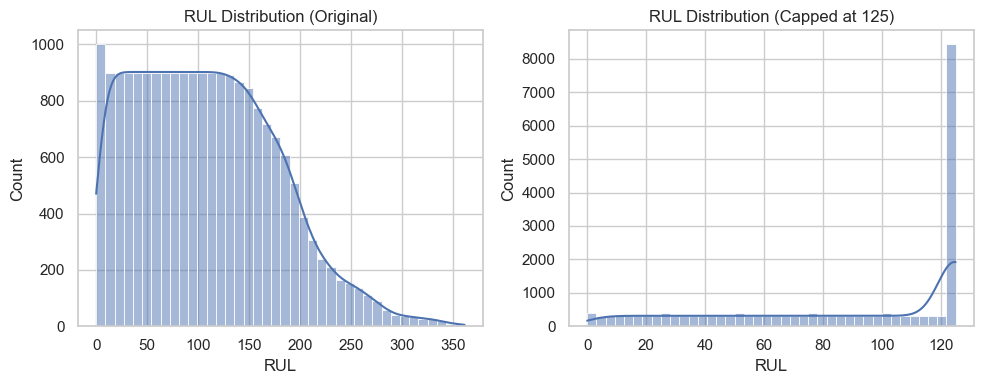

RUL after capping — max: 125


In [209]:
# RUL capping: Treat >= 125 cycles as 'sufficiently remaining' (CMAPSS standard)
RUL_CAP = 125
train_model['RUL'] = train_model['RUL'].clip(upper=RUL_CAP)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(train['RUL'], bins=40, kde=True)
plt.title('RUL Distribution (Original)')
plt.subplot(1, 2, 2)
sns.histplot(train_model['RUL'], bins=40, kde=True)
plt.title(f'RUL Distribution (Capped at {RUL_CAP})')
plt.tight_layout()
plt.savefig('outputs/figures/rul_capping_comparison.png', dpi=120)
plt.show()
print('RUL after capping — max:', train_model['RUL'].max())


### 4-2. Feature Generation

| Feature | Description |
|---|---|
| `{col}_rolling_mean_5/10/20` | Moving average with window size 5/10/20 |
| `{col}_rolling_std_5/10/20` | Moving standard deviation with window size 5/10/20 |
| `{col}_ewma` | Exponentially Weighted Moving Average (span=10) |
| `{col}_diff` | 1-cycle first-order difference |
| `{col}_cmin` / `cmax` / `crange` | Cumulative minimum / maximum / range |
| `{col}_deg_ratio` | rolling_mean_5 / initial average of 5 cycles (Degradation ratio) |

In [210]:
WINDOWS = [5, 10, 20]

# Efficient feature generation: Collect in dict and merge at once using pd.concat
new_feature_dict = {}

for col in sensor_cols:
    grp = train_model.groupby('engine_id')[col]

    # --- ADVANCED: Per-Engine Baseline Subtraction ---
    # Subtracting the initial calm state removes manufacturing variation
    initial_mean = train_model[train_model['cycle'] <= 10].groupby('engine_id')[col].mean()
    initial_mean_mapped = train_model['engine_id'].map(initial_mean)
    new_feature_dict[f'{col}_base_sub'] = train_model[col] - initial_mean_mapped
    # ------------------------------------------------

    # Multi-window rolling mean & std
    for w in WINDOWS:
        new_feature_dict[f'{col}_rolling_mean_{w}'] = (
            grp.rolling(w).mean().reset_index(level=0, drop=True)
        )
        new_feature_dict[f'{col}_rolling_std_{w}'] = (
            grp.rolling(w).std().reset_index(level=0, drop=True)
        )

    # EWMA: Higher weight on recent values, robust to noise
    new_feature_dict[f'{col}_ewma'] = (
        grp.transform(lambda x: x.ewm(span=10, adjust=False).mean())
    )

    # 1st diff (Rate of change)
    new_feature_dict[f'{col}_diff'] = grp.diff()

    # Cumulative statistics (track overall degradation range of engine)
    new_feature_dict[f'{col}_cmin'] = grp.cummin()
    new_feature_dict[f'{col}_cmax'] = grp.cummax()
    new_feature_dict[f'{col}_crange'] = (
        grp.cummax() - grp.cummin()
    )

    # Degradation ratio: rolling_mean_5 / initial 5-cycle average
    # Initial average is calculated per engine within train (no leakage)
    initial_mean_5 = (
        train_model[train_model['cycle'] <= 5]
        .groupby('engine_id')[col]
        .mean()
    )
    initial_mean_mapped_5 = train_model['engine_id'].map(initial_mean_5)
    rolling_m5 = grp.rolling(5).mean().reset_index(level=0, drop=True)
    # Prevent division by 0 (for sensors with small absolute values)
    new_feature_dict[f'{col}_deg_ratio'] = (
        rolling_m5 / initial_mean_mapped_5.replace(0, np.nan)
    )

# Concat at once (prevents fragmentation)
new_features_df = pd.DataFrame(new_feature_dict, index=train_model.index)
train_model = pd.concat([train_model, new_features_df], axis=1)

print('Feature matrix shape before dropna:', train_model.shape)

Feature matrix shape before dropna: (20631, 216)


In [211]:
train_model = train_model.dropna().copy()
print('Feature matrix shape after dropna:', train_model.shape)


Feature matrix shape after dropna: (18731, 216)


### 4-3. Feature Matrix Construction

All engineered features are used except for `engine_id`, `cycle`, and `RUL`.

In [212]:
feature_cols = [
    col for col in train_model.columns
    if col not in ['engine_id', 'cycle', 'RUL']
]

X = train_model[feature_cols]
y = train_model['RUL']

print(f'Feature count: {len(feature_cols)}')
print(X.shape)


Feature count: 213
(18731, 213)


## 5. Model Training & Validation

In [213]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    test_size=0.2,
    n_splits=1,
    random_state=42
)

train_idx, val_idx = next(gss.split(X, y, groups=train_model['engine_id']))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

print('Train size:', X_train.shape)
print('Val size:', X_val.shape)


Train size: (15041, 213)
Val size: (3690, 213)


In [214]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

lgbm_quick = LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgbm_quick.fit(X_train, y_train)

pred_val = lgbm_quick.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))

print('LightGBM quick Validation RMSE:', rmse_val)


LightGBM quick Validation RMSE: 13.62298599869718


In [215]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LassoCV, BayesianRidge
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. Operational Settings Clustering Regressor
class SettingClusterRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, base_config_model=None, n_clusters=3, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        # Using LGBM as a fast and stable standard template if None
        self.base_config_model = base_config_model if base_config_model is not None else LGBMRegressor(n_estimators=100, max_depth=6, n_jobs=-1, random_state=random_state, verbose=-1)
        self.models = []
        
    def _extract_settings(self, X):
        cols = ['setting_1', 'setting_2']
        available = [c for c in cols if c in X.columns]
        if len(available) == 0:
            return np.zeros((X.shape[0], 2))
        elif len(available) == 1:
            return X[[available[0], available[0]]].values
        return X[cols].values

    def fit(self, X, y):
        settings_data = self._extract_settings(X)
        clusters = self.kmeans.fit_predict(settings_data)
        
        from sklearn.base import clone
        for i in range(self.n_clusters):
            model = clone(self.base_config_model)
            mask = (clusters == i)
            if mask.sum() > 0:
                model.fit(X.loc[mask], y.loc[mask])
            self.models.append(model)
        return self

    def predict(self, X):
        settings_data = self._extract_settings(X)
        clusters = self.kmeans.predict(settings_data)
        predictions = np.zeros(X.shape[0])
        
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if mask.sum() > 0:
                predictions[mask] = self.models[i].predict(X.loc[mask])
        
        return np.clip(predictions, 0, 125)

# 2. Candidate Models (All Wrapped in SettingsAware)
models = {
    'SettingsAware_LassoCV': SettingClusterRegressor(
        base_config_model=Pipeline([
            ('scaler', StandardScaler()), 
            ('LassoCV', LassoCV(cv=2, random_state=42, max_iter=1000))
        ])
    ),
    'SettingsAware_LinearSVR': SettingClusterRegressor(
        base_config_model=Pipeline([
            ('scaler', StandardScaler()), 
            ('SVR', LinearSVR(random_state=42, max_iter=2000, C=1.0))
        ])
    ),
    'SettingsAware_RandomForest': SettingClusterRegressor(
        base_config_model=RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_split=4, n_jobs=-1, random_state=42)
    ),
    'SettingsAware_LightGBM': SettingClusterRegressor(
        base_config_model=LGBMRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42, verbose=-1)
    ),
    'SettingsAware_XGBoost': SettingClusterRegressor(
        base_config_model=XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42, verbosity=0)
    ),
    'SettingsAware_CatBoost': SettingClusterRegressor(
        base_config_model=CatBoostRegressor(iterations=150, depth=6, learning_rate=0.05, verbose=0, random_state=42)
    ),
    'SettingsAware_HistGB': SettingClusterRegressor(
        base_config_model=HistGradientBoostingRegressor(max_iter=150, max_depth=6, learning_rate=0.05, random_state=42)
    )
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
    results[name] = rmse_val
    print(f'{name} Validation RMSE: {rmse_val:.4f}')

print("""
=== Final HPO & Settings Comparison Results ===""")
for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f'{name}: {rmse:.4f}')

best_model_name = min(results, key=results.get)
best_rmse = results[best_model_name]

print(f"""
best model: {best_model_name} (RMSE: {best_rmse:.4f})""")

pred_val = models[best_model_name].predict(X_val)
final_model = models[best_model_name]
final_model.fit(X, y)

print(f"""
final model ({best_model_name}) retrained on full dataset""")


SettingsAware_LassoCV Validation RMSE: 16.1153
SettingsAware_LinearSVR Validation RMSE: 17.9744
SettingsAware_RandomForest Validation RMSE: 12.6726
SettingsAware_LightGBM Validation RMSE: 13.1945
SettingsAware_XGBoost Validation RMSE: 13.3544
SettingsAware_CatBoost Validation RMSE: 13.8814
SettingsAware_HistGB Validation RMSE: 13.3091

=== Final HPO & Settings Comparison Results ===
SettingsAware_RandomForest: 12.6726
SettingsAware_LightGBM: 13.1945
SettingsAware_HistGB: 13.3091
SettingsAware_XGBoost: 13.3544
SettingsAware_CatBoost: 13.8814
SettingsAware_LassoCV: 16.1153
SettingsAware_LinearSVR: 17.9744

best model: SettingsAware_RandomForest (RMSE: 12.6726)

final model (SettingsAware_RandomForest) retrained on full dataset


In [216]:
# ==========================================
# 5-2. Segment-wise Residual Analysis (Heteroscedasticity Check)
# ==========================================
import pandas as pd
import numpy as np

# We test performance of the Linear Baseline vs Gradient Boosting implementations
name_linear = 'SettingsAware_LassoCV'
name_lgbm = 'SettingsAware_LightGBM'
name_xgb = 'SettingsAware_XGBoost'

pred_lin = models[name_linear].predict(X_val)
pred_lgbm = models[name_lgbm].predict(X_val)
pred_xgb = models[name_xgb].predict(X_val)

df_eval = pd.DataFrame({
    'True_RUL': y_val,
    'Linear_Pred': pred_lin,
    'LGBM_Pred': pred_lgbm,
    'XGB_Pred': pred_xgb
})

df_eval['Linear_Residual'] = df_eval['True_RUL'] - df_eval['Linear_Pred']
df_eval['LGBM_Residual'] = df_eval['True_RUL'] - df_eval['LGBM_Pred']
df_eval['XGB_Residual'] = df_eval['True_RUL'] - df_eval['XGB_Pred']

def get_segment(rul):
    if rul <= 30: return '1. RUL <= 30'
    elif rul <= 60: return '2. 30 < RUL <= 60'
    elif rul <= 115: return '3. 60 < RUL <= 115'
    else: return '4. RUL > 115'

df_eval['Segment'] = df_eval['True_RUL'].apply(get_segment)

# Calculate Standard Deviation of Residuals
res_std = df_eval.groupby('Segment')[['Linear_Residual', 'LGBM_Residual', 'XGB_Residual']].std().round(2)
print("Standard Deviation of Residuals by Segment (Lower is Better)")
print(res_std)

print("""
Analysis:
- Linear_Residual: Settings-Aware Linear Baseline
- LGBM_Residual: Settings-Aware LightGBM
- XGB_Residual: Settings-Aware XGBoost""")


Standard Deviation of Residuals by Segment (Lower is Better)
                    Linear_Residual  LGBM_Residual  XGB_Residual
Segment                                                         
1. RUL <= 30                  14.45           5.74          5.70
2. 30 < RUL <= 60             14.58          15.46         15.11
3. 60 < RUL <= 115            13.87          17.68         17.82
4. RUL > 115                   8.10           6.15          6.64

Analysis:
- Linear_Residual: Settings-Aware Linear Baseline
- LGBM_Residual: Settings-Aware LightGBM
- XGB_Residual: Settings-Aware XGBoost


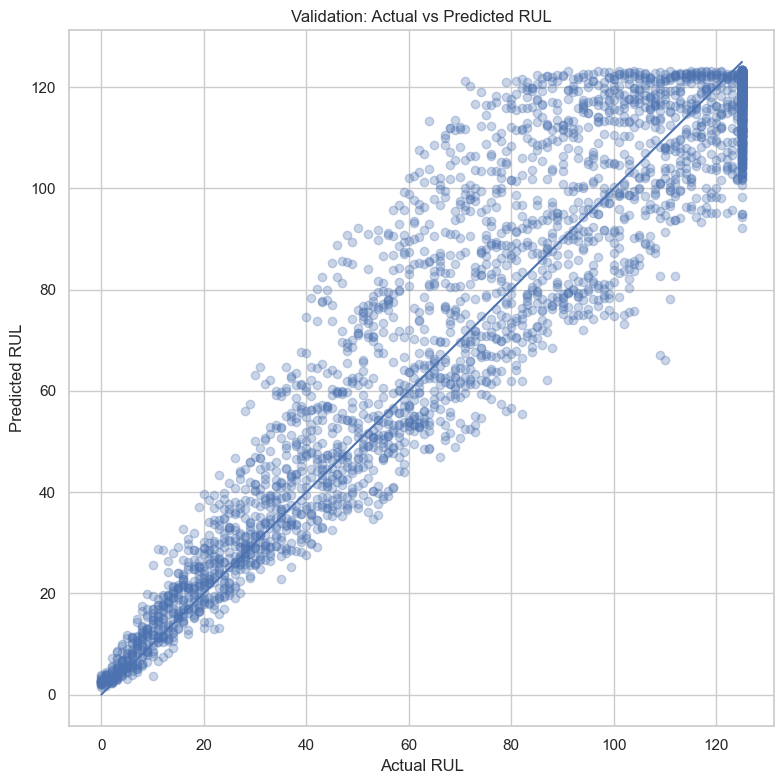

In [217]:
plt.figure(figsize=(8, 8))

plt.scatter(y_val, pred_val, alpha=0.3)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()]
)

plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')

plt.title('Validation: Actual vs Predicted RUL')
plt.tight_layout()
plt.savefig('outputs/figures/val_scatter.png', dpi=120)
plt.show()


In [218]:
columns = (
    ['engine_id', 'cycle'] +
    [f'setting_{i}' for i in range(1, 4)] +
    [f'sensor_{i}' for i in range(1, 22)]
)

test = pd.read_csv(
    'data/test_FD001.txt',
    sep=r'\s+',
    header=None
)

test = test.iloc[:, :26]
test.columns = columns

print(test.shape)


(13096, 26)


In [219]:
constant_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

test = test.drop(columns=constant_sensors).copy()
test_model = test.copy()

print(test.shape)


(13096, 20)


## 6. Test Data Feature Engineering

The exact same feature pipeline from Train is applied to Test.  
> **Degradation ratio baseline** is calculated using the initial 5 cycles of the test engine itself (no leakage).  
> `cycle_ratio` is **excluded** because it requires the engine's lifespan (future information) during test phase.

In [220]:
WINDOWS = [5, 10, 20]

new_test_feature_dict = {}

for col in sensor_cols:
    grp = test_model.groupby('engine_id')[col]

    # --- ADVANCED: Per-Engine Baseline Subtraction ---
    initial_mean_test_10 = test_model[test_model['cycle'] <= 10].groupby('engine_id')[col].mean()
    # Fallback to mean of all if engine is too short
    if initial_mean_test_10.isna().any():
        initial_mean_test_10 = initial_mean_test_10.fillna(test_model.groupby('engine_id')[col].mean())
    
    initial_mean_mapped_test = test_model['engine_id'].map(initial_mean_test_10)
    new_test_feature_dict[f'{col}_base_sub'] = test_model[col] - initial_mean_mapped_test
    # ------------------------------------------------

    for w in WINDOWS:
        new_test_feature_dict[f'{col}_rolling_mean_{w}'] = (
            grp.rolling(w).mean().reset_index(level=0, drop=True)
        )
        new_test_feature_dict[f'{col}_rolling_std_{w}'] = (
            grp.rolling(w).std().reset_index(level=0, drop=True)
        )

    new_test_feature_dict[f'{col}_ewma'] = (
        grp.transform(lambda x: x.ewm(span=10, adjust=False).mean())
    )
    new_test_feature_dict[f'{col}_diff'] = grp.diff()
    new_test_feature_dict[f'{col}_cmin'] = grp.cummin()
    new_test_feature_dict[f'{col}_cmax'] = grp.cummax()
    new_test_feature_dict[f'{col}_crange'] = (
        grp.cummax() - grp.cummin()
    )

    # baseline: test initial 5 cycles
    initial_mean_test = (
        test_model[test_model['cycle'] <= 5]
        .groupby('engine_id')[col]
        .mean()
    )
    if initial_mean_test.isna().any():
        initial_mean_test = initial_mean_test.fillna(test_model.groupby('engine_id')[col].mean())
        
    initial_mean_mapped = test_model['engine_id'].map(initial_mean_test)
    rolling_m5 = grp.rolling(5).mean().reset_index(level=0, drop=True)
    new_test_feature_dict[f'{col}_deg_ratio'] = (
        rolling_m5 / initial_mean_mapped.replace(0, np.nan)
    )

new_test_features_df = pd.DataFrame(new_test_feature_dict, index=test_model.index)
test_model = pd.concat([test_model, new_test_features_df], axis=1)

test_model = test_model.dropna().copy()
print('Test feature matrix shape:', test_model.shape)

Test feature matrix shape: (11196, 215)


In [221]:
test_last = test_model.groupby('engine_id').tail(1).copy()

print(test_last.shape)


(100, 215)


## 7. Test Prediction & Evaluation

In [222]:
X_test = test_last[feature_cols]

test_last['predicted_RUL'] = final_model.predict(X_test)

test_last['predicted_RUL'].describe()


count    100.000000
mean      74.578107
std       37.896587
min        7.625988
25%       37.654761
50%       85.937047
75%      107.559913
max      122.811624
Name: predicted_RUL, dtype: float64

In [223]:
rul_test = pd.read_csv('data/RUL_FD001.txt', header=None)

rul_test.columns = ['true_RUL']

test_last = test_last.sort_values('engine_id').reset_index(drop=True)

test_last['true_RUL'] = rul_test['true_RUL']


In [224]:
# Fair evaluation based on RUL Capping
# Model was trained on RUL_CAP=125, so true_RUL is also clipped for comparison
RUL_CAP = 125
test_last['true_RUL_capped'] = test_last['true_RUL'].clip(upper=RUL_CAP)

rmse_test_raw = np.sqrt(
    mean_squared_error(
        test_last['true_RUL'],
        test_last['predicted_RUL']
    )
)
rmse_test_capped = np.sqrt(
    mean_squared_error(
        test_last['true_RUL_capped'],
        test_last['predicted_RUL']
    )
)

print(f'Test RMSE (vs original true_RUL):           {rmse_test_raw:.4f}')
print(f'Test RMSE (vs capped true_RUL, cap={RUL_CAP}):  {rmse_test_capped:.4f}')
print()
print('[Ref] Previous Baseline Test RMSE (raw): 33.02')
print('=> Compare the Capped RMSE to verify the improvement')


Test RMSE (vs original true_RUL):           15.5938
Test RMSE (vs capped true_RUL, cap=125):  14.3101

[Ref] Previous Baseline Test RMSE (raw): 33.02
=> Compare the Capped RMSE to verify the improvement


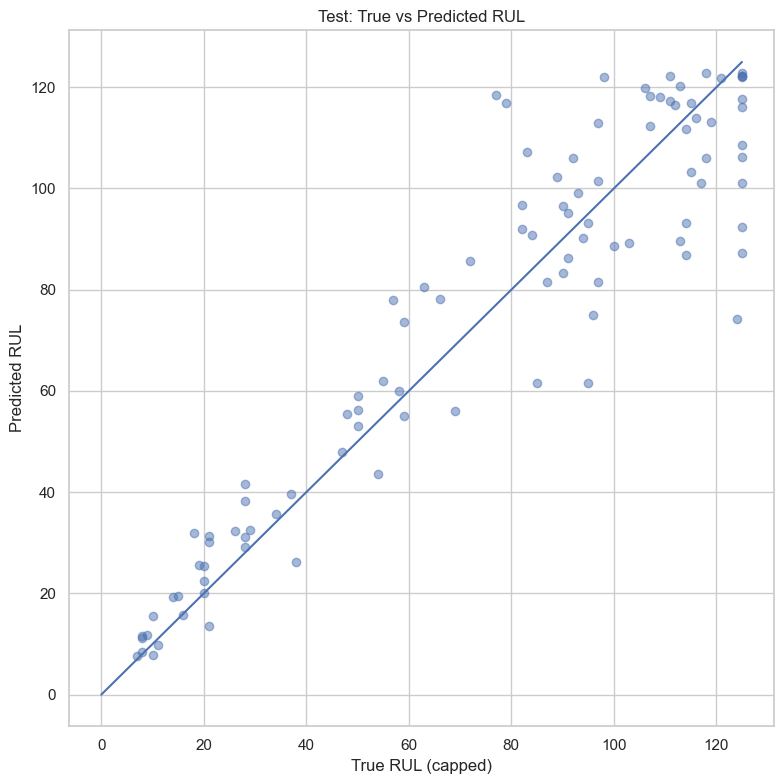

In [225]:
plt.figure(figsize=(8, 8))

plt.scatter(
    test_last['true_RUL_capped'],
    test_last['predicted_RUL'],
    alpha=0.5
)

plt.plot(
    [0, max(test_last['true_RUL_capped'])],
    [0, max(test_last['true_RUL_capped'])]
)

plt.xlabel('True RUL (capped)')
plt.ylabel('Predicted RUL')
plt.title('Test: True vs Predicted RUL')
plt.tight_layout()
plt.savefig('outputs/figures/test_scatter.png', dpi=120)
plt.show()


In [226]:
# Feature Importance (If Supported by Best Model)
import numpy as np

# Handle RandomizedSearchCV wrapping
model_to_check = final_model
if hasattr(final_model, 'best_estimator_'):
    model_to_check = final_model.best_estimator_

if hasattr(model_to_check, 'feature_importances_'):
    import pandas as pd
    import matplotlib.pyplot as plt
    importance = pd.Series(
        model_to_check.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

    top15 = importance.head(15)

    plt.figure(figsize=(10, 6))

    top15.sort_values().plot(kind='barh')
    plt.title('Top 15 Feature Importance')
    plt.tight_layout()
    plt.savefig('outputs/figures/feature_importance.png', dpi=120)
    plt.show()

    print('Top 15 features:')
    for feat, imp in top15.items():
        print(f'  {feat}: {imp:.4f}')
else:
    print('Feature importance not supported by the final architecture (e.g., SettingClusterRegressor or LinearSVR).')


Feature importance not supported by the final architecture (e.g., SettingClusterRegressor or LinearSVR).


In [227]:
fleet_risk = test_last[['engine_id', 'predicted_RUL']].copy()

fleet_risk = fleet_risk.sort_values('predicted_RUL').reset_index(drop=True)

fleet_risk.head(15)


,engine_id,predicted_RUL
0,34,7.625988
1,76,7.894176
2,81,8.456648
3,35,9.832206
4,68,11.244917
5,31,11.609141
6,82,11.864757
7,49,13.474677
8,42,15.531100
9,20,15.778282


In [228]:
def risk_level(rul):
    if rul < 20:
        return 'High'
    elif rul < 50:
        return 'Medium'
    else:
        return 'Low'

fleet_risk['risk_level'] = fleet_risk['predicted_RUL'].apply(risk_level)

fleet_risk.head(20)


,engine_id,predicted_RUL,risk_level
0,34,7.625988,High
1,76,7.894176,High
2,81,8.456648,High
3,35,9.832206,High
4,68,11.244917,High
5,31,11.609141,High
6,82,11.864757,High
7,49,13.474677,High
8,42,15.531100,High
9,20,15.778282,High


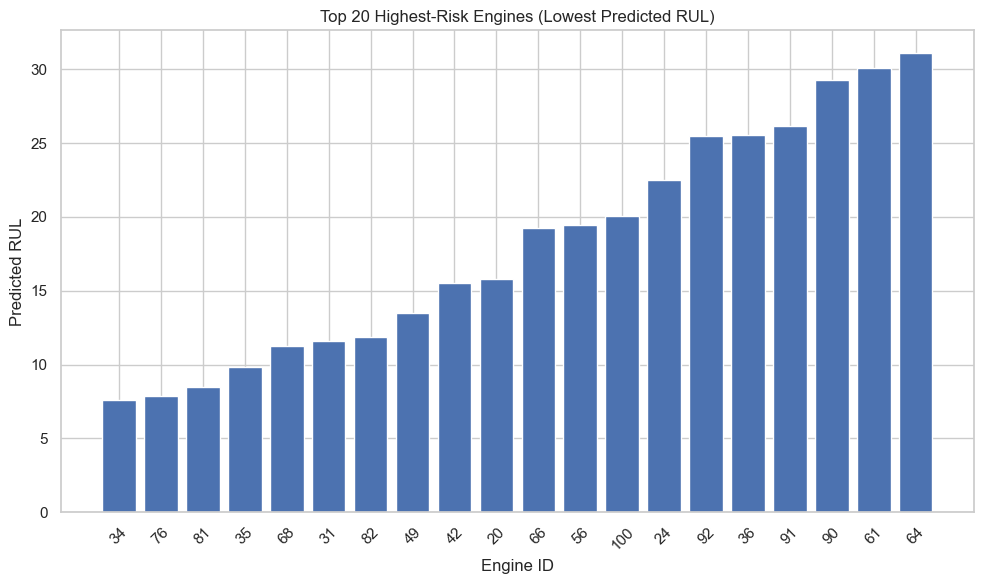

In [229]:
plt.figure(figsize=(10, 6))

top_risk = fleet_risk.head(20)

plt.bar(
    top_risk['engine_id'].astype(str),
    top_risk['predicted_RUL']
)

plt.xlabel('Engine ID')
plt.ylabel('Predicted RUL')

plt.title('Top 20 Highest-Risk Engines (Lowest Predicted RUL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/figures/top_risk_engines.png', dpi=120)
plt.show()


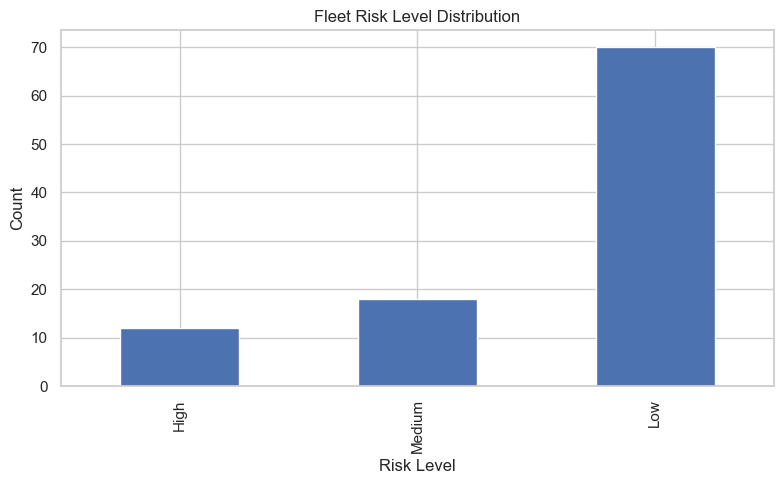

risk_level
High      12
Medium    18
Low       70
Name: count, dtype: int64


In [230]:
risk_counts = fleet_risk['risk_level'].value_counts().reindex(['High', 'Medium', 'Low'])

plt.figure(figsize=(8, 5))

risk_counts.plot(kind='bar')
plt.title('Fleet Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/figures/risk_distribution.png', dpi=120)
plt.show()

print(risk_counts)


In [231]:
fleet_risk.to_csv('outputs/fleet_risk_table.csv', index=False)

test_last[['engine_id', 'true_RUL', 'true_RUL_capped', 'predicted_RUL']].to_csv(
    'outputs/test_predictions.csv',
    index=False
)

if 'top15' in locals():
    top15.to_csv('outputs/feature_importance_top15.csv')

print('Files saved to outputs/')


Files saved to outputs/


## 8. eXplainable AI (XAI) for Front-line Operators

To ensure our Predictive Maintenance model is not a "Black Box", we apply **SHAP (SHapley Additive exPlanations)**.
This allows mechanics and engineers to physically verify *why* the model predicts imminent failure for an engine.

Initializing SHAP Explainer on the Final Settings-Aware Model...
Computing SHAP values for the test fleet...


PermutationExplainer explainer: 101it [01:00,  1.58it/s]                         



1. GLOBAL ANALYSIS (Which sensors matter most fleet-wide?)


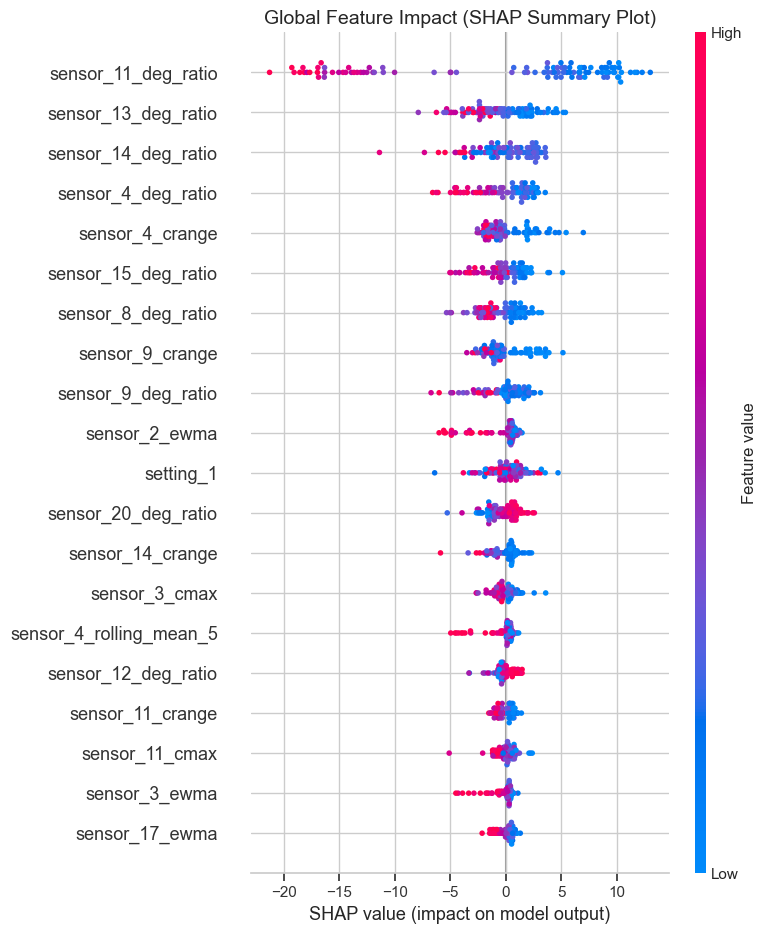


2. LOCAL ANALYSIS (Why is a specific engine failing?)
Diagnostics for Highest Risk Engine ID: 34
Predicted Remaining Useful Life (RUL): 7.63 cycles



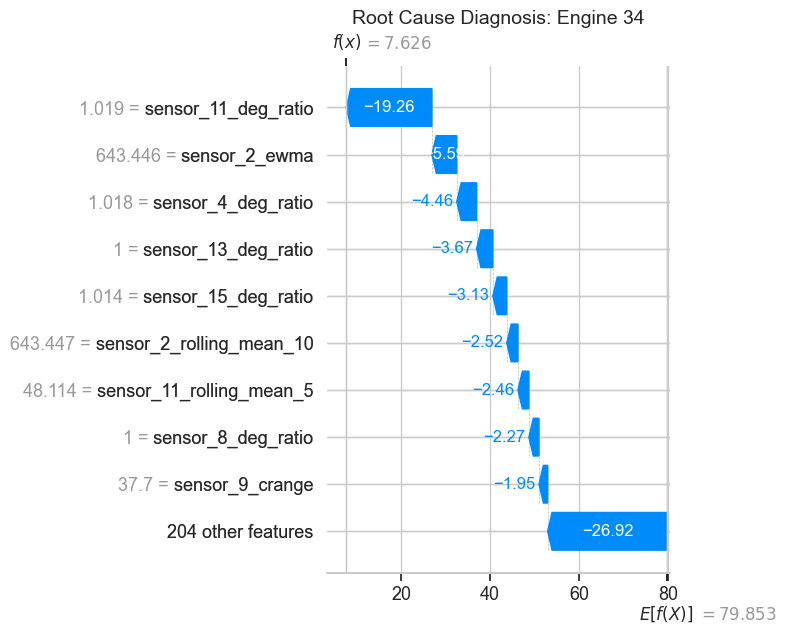

In [232]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Initialize Javascript visualization for SHAP
shap.initjs()

print("Initializing SHAP Explainer on the Final Settings-Aware Model...")

# 1. Background Dataset (for Permutation Explainer)
# We sample 100 typical operational states from train to act as a baseline
background = X_train.sample(100, random_state=42)

# We use the model-agnostic Permutation explainer because our SettingClusterRegressor
# is a complex composite wrapper around multiple sub-models
explainer = shap.Explainer(final_model.predict, background)

# 2. Get SHAP values for ALL test engines (their final recorded cycle)
print("Computing SHAP values for the test fleet...")
shap_values = explainer(X_test)

# --- GLOBAL INTERPRETABILITY ---
print("""
======================================================
1. GLOBAL ANALYSIS (Which sensors matter most fleet-wide?)
======================================================""")
plt.figure(figsize=(10, 6))
plt.title("Global Feature Impact (SHAP Summary Plot)", fontsize=14)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('outputs/figures/shap_summary_global.png', dpi=120)
plt.show()

# --- LOCAL INTERPRETABILITY ---
print("""
======================================================
2. LOCAL ANALYSIS (Why is a specific engine failing?)
======================================================""")

# Find the engine with the lowest predicted RUL in the fleet
# using np.argmin to be robust to index sorting mismatches
worst_iloc = np.argmin(test_last['predicted_RUL'])
worst_engine_id = int(test_last.iloc[worst_iloc]['engine_id'])
worst_rul_pred = test_last.iloc[worst_iloc]['predicted_RUL']

print(f"Diagnostics for Highest Risk Engine ID: {worst_engine_id}")
print(f"Predicted Remaining Useful Life (RUL): {worst_rul_pred:.2f} cycles\n")

# Generate a Waterfall Plot for this exact engine
# This shows exactly how each sensor pulled the RUL down from the average baseline
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[worst_iloc], max_display=10, show=False)
plt.title(f"Root Cause Diagnosis: Engine {worst_engine_id}", fontsize=14)
plt.tight_layout()
plt.savefig(f'outputs/figures/shap_waterfall_engine_{worst_engine_id}.png', dpi=120)
plt.show()
